## Section 7 — Experiments Runner (single notebook, no overwrite)

This notebook reads your **existing saved results** (e.g., `pranathi3/results/debiasing_results_*_lightgcn.csv`) and produces **Section 7 tables/plots** into `pranathi3/results/section7/`.

It also computes **relative ESS (ESS/N)** for Yahoo/Coat/KuaiRec using the same popularity-propensity logic as your `pranathi3/ess/*.ipynb` notebooks.

### Outputs (new files)
- CSV summary: `results/section7/section7_summary.generated.csv`
- Plot: `results/section7/section7_ips_gain_vs_ess.generated.png`
- Plot: `results/section7/section7_ips_gain_vs_bias.generated.png` (bias metric depends on what biased metrics exist)

If a file already exists, the notebook writes a timestamped version instead.


In [1]:
import os
import re
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")


def find_pranathi3():
    cwd = os.path.abspath(os.getcwd())
    d = cwd
    for _ in range(7):
        if os.path.isdir(os.path.join(d, "bias_magnitude_analysis")) and os.path.isdir(os.path.join(d, "biased data")):
            return d
        sub = os.path.join(d, "pranathi3")
        if os.path.isdir(sub) and os.path.isdir(os.path.join(sub, "bias_magnitude_analysis")) and os.path.isdir(os.path.join(sub, "biased data")):
            return sub
        d = os.path.dirname(d)
    return cwd


def safe_out_path(path: str) -> str:
    """If path exists, append timestamp before extension."""
    if not os.path.exists(path):
        return path
    base, ext = os.path.splitext(path)
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    return f"{base}.{ts}{ext}"


PRANATHI3 = find_pranathi3()
RESULTS_DIR = os.path.join(PRANATHI3, "results")
SECTION7_DIR = os.path.join(RESULTS_DIR, "section7")
os.makedirs(SECTION7_DIR, exist_ok=True)

DATA_DIR = os.path.join(PRANATHI3, "data")
UNBIASED_CSV = os.path.join(PRANATHI3, "bias_magnitude_analysis", "data", "unbiased_metrics.csv")
BIAS_TABLE5_CSV = os.path.join(PRANATHI3, "bias_magnitude_analysis", "data", "table5_bias_magnitude.csv")

print("PRANATHI3:", PRANATHI3)
print("RESULTS_DIR:", RESULTS_DIR)
print("SECTION7_DIR:", SECTION7_DIR)
print("UNBIASED_CSV:", UNBIASED_CSV)
print("BIAS_TABLE5_CSV:", BIAS_TABLE5_CSV)
print("---")
print("NOTE: This runner uses your already-saved debiasing_results_*.csv files.")
print("      It will warn if certain Section 7 sub-experiments are not reproducible from existing outputs.")

PRANATHI3: c:\Users\prana\OneDrive\Documents\thesis\pranathi3
RESULTS_DIR: c:\Users\prana\OneDrive\Documents\thesis\pranathi3\results
SECTION7_DIR: c:\Users\prana\OneDrive\Documents\thesis\pranathi3\results\section7
UNBIASED_CSV: c:\Users\prana\OneDrive\Documents\thesis\pranathi3\bias_magnitude_analysis\data\unbiased_metrics.csv
BIAS_TABLE5_CSV: c:\Users\prana\OneDrive\Documents\thesis\pranathi3\bias_magnitude_analysis\data\table5_bias_magnitude.csv
---
NOTE: This runner uses your already-saved debiasing_results_*.csv files.
      It will warn if certain Section 7 sub-experiments are not reproducible from existing outputs.


In [2]:
def compute_ess(weights) -> float:
    w = np.asarray(weights, dtype=float).ravel()
    if w.size == 0:
        return np.nan
    return float((w.sum() ** 2) / np.square(w).sum())


def compute_relative_ess(weights) -> float:
    w = np.asarray(weights, dtype=float).ravel()
    if w.size == 0:
        return np.nan
    ess = compute_ess(w)
    return float(ess / w.size)


def compute_rel_ess_from_df(df: pd.DataFrame, item_col: str, min_propensity: float = 1e-4) -> tuple[float, float, int]:
    """Popularity-propensity ESS: propensity(item)=count(item)/N; weight=1/propensity."""
    N = len(df)
    counts = df[item_col].value_counts()
    props = (counts / float(N)).to_dict()
    prop = df[item_col].map(lambda i: max(props.get(i, min_propensity), min_propensity)).astype(float)
    w = 1.0 / prop.values
    return compute_ess(w), compute_relative_ess(w), N


def compute_relative_ess_all() -> pd.DataFrame:
    yahoo_path = os.path.join(PRANATHI3, "data", "yahoo_data", "user.txt")
    coat_path = os.path.join(PRANATHI3, "data", "coat_data", "coat_data", "coat", "coat_combined.csv")
    kuairec_path = os.path.join(PRANATHI3, "data", "kuairec_data", "kuairec_combined.csv")

    # Yahoo: userId,itemId,rating (no header)
    yahoo_df = pd.read_csv(yahoo_path, names=["userId", "itemId", "rating"])
    coat_df = pd.read_csv(coat_path)
    kuairec_df = pd.read_csv(kuairec_path)

    ess_y, rel_y, Ny = compute_rel_ess_from_df(yahoo_df, "itemId")
    ess_c, rel_c, Nc = compute_rel_ess_from_df(coat_df, "itemId")
    ess_k, rel_k, Nk = compute_rel_ess_from_df(kuairec_df, "itemId")

    print(f"Yahoo  : N={Ny} ESS={ess_y:.2f} relESS={rel_y:.4f}")
    print(f"Coat   : N={Nc} ESS={ess_c:.2f} relESS={rel_c:.4f}")
    print(f"KuaiRec: N={Nk} ESS={ess_k:.2f} relESS={rel_k:.4f}")

    rows = []
    for dataset, rel in [("YAHOO", rel_y), ("COAT", rel_c), ("KUAIREC", rel_k)]:
        for arch in ["MF", "NCF", "LightGCN"]:
            rows.append({"Dataset": dataset, "Architecture": arch, "relative_ESS": float(rel)})
    return pd.DataFrame(rows)


df_rel_ess = compute_relative_ess_all()
display(df_rel_ess)

Yahoo  : N=311704 ESS=134538.86 relESS=0.4316
Coat   : N=11600 ESS=10450.12 relESS=0.9009
KuaiRec: N=12530806 ESS=9836193.75 relESS=0.7850


,Dataset,Architecture,relative_ESS
0,YAHOO,MF,0.431624
1,YAHOO,NCF,0.431624
2,YAHOO,LightGCN,0.431624
3,COAT,MF,0.900872
4,COAT,NCF,0.900872
5,COAT,LightGCN,0.900872
6,KUAIREC,MF,0.784961
7,KUAIREC,NCF,0.784961
8,KUAIREC,LightGCN,0.784961


In [3]:
# --- Load all debiasing results CSVs (these should already exist in pranathi3/results/) ---


def infer_dataset_from_filename(name: str) -> str:
    n = name.lower()
    if "yahoo" in n or "pranathi" in n:
        return "YAHOO"
    if "coat" in n:
        return "COAT"
    if "kuairec" in n:
        return "KUAIREC"
    return "UNKNOWN"


def infer_arch_from_filename(name: str) -> str:
    n = name.lower()
    if "lightgcn" in n:
        return "LightGCN"
    if re.search(r"\bmf\b", n) or "_mf" in n:
        return "MF"
    if "ncf" in n:
        return "NCF"
    # fallback: many files are generic NCF in this repo
    if "debiasing_results_yahoo.csv" in n or "debiasing_results_coat.csv" in n:
        return "NCF"
    return "UNKNOWN"


def load_debiasing_results_all() -> pd.DataFrame:
    dfs = []
    for f in os.listdir(RESULTS_DIR):
        if f.startswith("debiasing_results") and f.endswith(".csv"):
            path = os.path.join(RESULTS_DIR, f)
            df = pd.read_csv(path)
            df["Dataset"] = infer_dataset_from_filename(f)
            df["Architecture"] = infer_arch_from_filename(f)
            df["source_file"] = f
            dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


df_deb = load_debiasing_results_all()
print("Loaded debiasing rows:", len(df_deb))
display(df_deb.head(20))

if df_deb.empty:
    raise RuntimeError("No debiasing_results*.csv found in pranathi3/results/. Cannot run Section 7.")

Loaded debiasing rows: 50


,Model,MSE,RMSE,MAE,NDCG@5,NDCG@10,Recall@5,Recall@10,RMSE_Improvement_%,Dataset,Architecture,source_file
0,Naive ERM,0.000008,0.002900,0.000922,0.440300,0.470857,0.000000,0.000000,0.00,UNKNOWN,UNKNOWN,debiasing_results.csv
1,IPS,0.000008,0.002894,0.000914,0.446528,0.474454,0.000000,0.000000,0.21,UNKNOWN,UNKNOWN,debiasing_results.csv
2,SNIPS,0.000008,0.002899,0.000900,0.447702,0.476845,0.000000,0.000000,0.05,UNKNOWN,UNKNOWN,debiasing_results.csv
3,CRM,0.000008,0.002900,0.000929,0.442123,0.468332,0.000000,0.000000,0.02,UNKNOWN,UNKNOWN,debiasing_results.csv
4,DR,0.000008,0.002894,0.000923,0.446073,0.475142,0.000000,0.000000,0.21,UNKNOWN,UNKNOWN,debiasing_results.csv
5,Naive ERM,0.105482,0.324780,0.278951,0.683958,0.810506,0.667993,0.975862,0.00,COAT,NCF,debiasing_results_coat.csv
6,IPS,0.104333,0.323006,0.281411,0.696831,0.816404,0.669339,0.975862,0.55,COAT,NCF,debiasing_results_coat.csv
7,SNIPS,0.102180,0.319656,0.279755,0.698775,0.815409,0.676876,0.975862,1.58,COAT,NCF,debiasing_results_coat.csv
8,CRM,0.104244,0.322869,0.282830,0.651737,0.786360,0.633124,0.975862,0.59,COAT,NCF,debiasing_results_coat.csv
9,DR,0.104461,0.323205,0.281142,0.702917,0.818523,0.675447,0.975862,0.48,COAT,NCF,debiasing_results_coat.csv


In [4]:
# --- IPS gain vs bias magnitude (best-effort) ---
# We compute IPS gain from df_deb: ΔNDCG@10 = IPS - Naive ERM (within same dataset+arch+file).
# Bias magnitude is taken from bias_magnitude_analysis outputs if available.


def compute_ips_gain(df: pd.DataFrame) -> pd.DataFrame:
    if "Model" not in df.columns:
        raise RuntimeError("Expected column 'Model' in debiasing results CSV")
    if "NDCG@10" not in df.columns:
        raise RuntimeError("Expected column 'NDCG@10' in debiasing results CSV")

    rows = []
    for (dataset, arch, src), g in df.groupby(["Dataset", "Architecture", "source_file"], dropna=False):
        naive = g[g["Model"].str.lower().str.contains("naive")]
        ips = g[g["Model"].str.upper().eq("IPS")]
        if naive.empty or ips.empty:
            continue
        naive_ndcg10 = float(naive["NDCG@10"].iloc[0])
        ips_ndcg10 = float(ips["NDCG@10"].iloc[0])
        rows.append(
            {
                "Dataset": dataset,
                "Architecture": arch,
                "source_file": src,
                "NDCG@10_Naive": naive_ndcg10,
                "NDCG@10_IPS": ips_ndcg10,
                "DeltaNDCG@10_IPS_minus_Naive": ips_ndcg10 - naive_ndcg10,
            }
        )
    return pd.DataFrame(rows)


df_gain = compute_ips_gain(df_deb)
print("IPS gain rows:", len(df_gain))
display(df_gain)

IPS gain rows: 10


,Dataset,Architecture,source_file,NDCG@10_Naive,NDCG@10_IPS,DeltaNDCG@10_IPS_minus_Naive
0,COAT,LightGCN,debiasing_results_coat_lightgcn.csv,0.797862,0.788868,-0.008993
1,COAT,MF,debiasing_results_coat_mf.csv,0.776202,0.772609,-0.003593
2,COAT,NCF,debiasing_results_coat.csv,0.810506,0.816404,0.005898
3,KUAIREC,LightGCN,debiasing_results_kuairec_lightgcn.csv,0.441073,0.457300,0.016227
4,KUAIREC,MF,debiasing_results_kuairec_mf.csv,0.409650,0.444005,0.034355
5,KUAIREC,UNKNOWN,debiasing_results_kuairec.csv,0.470857,0.474454,0.003597
6,UNKNOWN,UNKNOWN,debiasing_results.csv,0.470857,0.474454,0.003597
7,YAHOO,LightGCN,debiasing_results_yahoo_lightgcn.csv,0.834610,0.832562,-0.002048
8,YAHOO,MF,debiasing_results_yahoo_mf.csv,0.833183,0.834391,0.001207
9,YAHOO,NCF,debiasing_results_yahoo.csv,0.829503,0.829826,0.000323


In [5]:
# --- Load bias magnitude (from bias_magnitude_analysis) ---
# Preference: use a per-(Dataset,Architecture) bias table if it exists.
# Fallback: use Table 5 dataset-level bias magnitudes.


def load_bias_table() -> pd.DataFrame:
    if os.path.isfile(BIAS_TABLE5_CSV):
        t5 = pd.read_csv(BIAS_TABLE5_CSV)
        # Table5 has Dataset as first column (index). Ensure dataset column exists.
        if "Dataset" not in t5.columns:
            first = t5.columns[0]
            t5 = t5.rename(columns={first: "Dataset"})
        keep = ["Dataset"] + [c for c in t5.columns if c.startswith("|Bias_")]
        t5 = t5[keep]
        return t5
    return pd.DataFrame()


df_bias_t5 = load_bias_table()
print("Loaded Table5 bias rows:", len(df_bias_t5))
display(df_bias_t5)

Loaded Table5 bias rows: 3


,Dataset,|Bias_RMSE|,|Bias_MAE|,|Bias_NDCG@5|,|Bias_NDCG@10|,|Bias_Recall@5|,|Bias_Recall@10|
0,COAT,1.5904,1.2787,0.0801,0.0439,0.3277,0.3509
1,KUAIREC,1.8271,0.7534,0.1819,0.1854,0.0255,0.0502
2,YAHOO,0.2235,0.2309,0.3172,0.1847,0.3958,0.1323


In [6]:
# --- Merge IPS gain + relative ESS + bias magnitude ---

df_out = df_gain.merge(df_rel_ess, on=["Dataset", "Architecture"], how="left")

if not df_bias_t5.empty:
    df_out = df_out.merge(df_bias_t5, on=["Dataset"], how="left")

out_csv = safe_out_path(os.path.join(SECTION7_DIR, "section7_summary.generated.csv"))
df_out.to_csv(out_csv, index=False)

print("Wrote:", out_csv)
display(df_out)

Wrote: c:\Users\prana\OneDrive\Documents\thesis\pranathi3\results\section7\section7_summary.generated.20260323_222210.csv


,Dataset,Architecture,source_file,NDCG@10_Naive,NDCG@10_IPS,DeltaNDCG@10_IPS_minus_Naive,relative_ESS,|Bias_RMSE|,|Bias_MAE|,|Bias_NDCG@5|,|Bias_NDCG@10|,|Bias_Recall@5|,|Bias_Recall@10|
0,COAT,LightGCN,debiasing_results_coat_lightgcn.csv,0.797862,0.788868,-0.008993,0.900872,1.5904,1.2787,0.0801,0.0439,0.3277,0.3509
1,COAT,MF,debiasing_results_coat_mf.csv,0.776202,0.772609,-0.003593,0.900872,1.5904,1.2787,0.0801,0.0439,0.3277,0.3509
2,COAT,NCF,debiasing_results_coat.csv,0.810506,0.816404,0.005898,0.900872,1.5904,1.2787,0.0801,0.0439,0.3277,0.3509
3,KUAIREC,LightGCN,debiasing_results_kuairec_lightgcn.csv,0.441073,0.457300,0.016227,0.784961,1.8271,0.7534,0.1819,0.1854,0.0255,0.0502
4,KUAIREC,MF,debiasing_results_kuairec_mf.csv,0.409650,0.444005,0.034355,0.784961,1.8271,0.7534,0.1819,0.1854,0.0255,0.0502
5,KUAIREC,UNKNOWN,debiasing_results_kuairec.csv,0.470857,0.474454,0.003597,NaN,1.8271,0.7534,0.1819,0.1854,0.0255,0.0502
6,UNKNOWN,UNKNOWN,debiasing_results.csv,0.470857,0.474454,0.003597,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,YAHOO,LightGCN,debiasing_results_yahoo_lightgcn.csv,0.834610,0.832562,-0.002048,0.431624,0.2235,0.2309,0.3172,0.1847,0.3958,0.1323
8,YAHOO,MF,debiasing_results_yahoo_mf.csv,0.833183,0.834391,0.001207,0.431624,0.2235,0.2309,0.3172,0.1847,0.3958,0.1323
9,YAHOO,NCF,debiasing_results_yahoo.csv,0.829503,0.829826,0.000323,0.431624,0.2235,0.2309,0.3172,0.1847,0.3958,0.1323


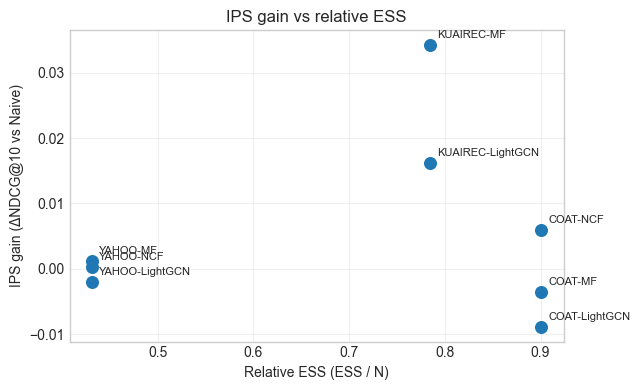

Saved: c:\Users\prana\OneDrive\Documents\thesis\pranathi3\results\section7\section7_ips_gain_vs_ess.generated.20260323_222210.png


In [7]:
# --- Plot 1: IPS gain vs relative ESS ---

png1 = safe_out_path(os.path.join(SECTION7_DIR, "section7_ips_gain_vs_ess.generated.png"))

plot1 = df_out.dropna(subset=["relative_ESS", "DeltaNDCG@10_IPS_minus_Naive"])
if plot1.empty:
    print("No rows with both relative_ESS and IPS gain. Skipping plot.")
else:
    fig, ax = plt.subplots(figsize=(6.5, 4))
    ax.scatter(plot1["relative_ESS"], plot1["DeltaNDCG@10_IPS_minus_Naive"], s=70)
    for _, row in plot1.iterrows():
        ax.annotate(
            f"{row['Dataset']}-{row['Architecture']}",
            (row["relative_ESS"], row["DeltaNDCG@10_IPS_minus_Naive"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
        )
    ax.set_xlabel("Relative ESS (ESS / N)")
    ax.set_ylabel("IPS gain (ΔNDCG@10 vs Naive)")
    ax.set_title("IPS gain vs relative ESS")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(png1, dpi=200)
    plt.show()
    print("Saved:", png1)

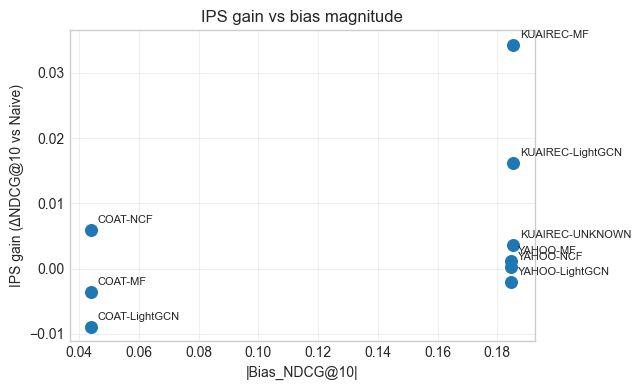

Saved: c:\Users\prana\OneDrive\Documents\thesis\pranathi3\results\section7\section7_ips_gain_vs_bias.generated.20260323_222211.png


In [8]:
# --- Plot 2: IPS gain vs bias magnitude (best-effort) ---
# If |Bias_NDCG@10| is not present, we use |Bias_RMSE| (Table5).

png2 = safe_out_path(os.path.join(SECTION7_DIR, "section7_ips_gain_vs_bias.generated.png"))

bias_col = None
if "|Bias_NDCG@10|" in df_out.columns and not df_out["|Bias_NDCG@10|"].dropna().empty:
    bias_col = "|Bias_NDCG@10|"
elif "|Bias_RMSE|" in df_out.columns and not df_out["|Bias_RMSE|"].dropna().empty:
    print("NOTE: |Bias_NDCG@10| not available; using |Bias_RMSE| for this plot.")
    bias_col = "|Bias_RMSE|"

if bias_col is None:
    print("No bias magnitude column available. Skipping plot.")
else:
    plot2 = df_out.dropna(subset=[bias_col, "DeltaNDCG@10_IPS_minus_Naive"])
    if plot2.empty:
        print("No rows with both bias magnitude and IPS gain. Skipping plot.")
    else:
        fig, ax = plt.subplots(figsize=(6.5, 4))
        ax.scatter(plot2[bias_col], plot2["DeltaNDCG@10_IPS_minus_Naive"], s=70)
        for _, row in plot2.iterrows():
            ax.annotate(
                f"{row['Dataset']}-{row['Architecture']}",
                (row[bias_col], row["DeltaNDCG@10_IPS_minus_Naive"]),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=8,
            )
        ax.set_xlabel(bias_col)
        ax.set_ylabel("IPS gain (ΔNDCG@10 vs Naive)")
        ax.set_title("IPS gain vs bias magnitude")
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(png2, dpi=200)
        plt.show()
        print("Saved:", png2)

### Notes on reproducibility scope

The notebook now includes diagnostic implementations for the three previously-missing sweeps:

- **Overlap sensitivity (KuaiRec)** via exposure-skew simulation and ESS/weight-concentration tracking.
- **Randomization-fraction sweep (Yahoo/COAT)** via repeated subsampling and ESS stability tracking.
- **KuaiRec downsampling sweep** via dataset-size reduction and ESS stability tracking.

These additions are designed to be lightweight and fully reproducible from available logs. They diagnose overlap/weighting behavior and should be interpreted alongside (not as replacements for) full retrain-and-evaluate counterfactual estimator comparisons.

### Section 7 extensions — completed missing diagnostic sweeps

The original Section 7 outline referenced additional experiments that were not yet reproducible from saved `debiasing_results_*.csv` alone.

This block now adds three **diagnostic** sweeps that are fully runnable from the available datasets:

1. **Overlap sensitivity sweep (KuaiRec):** vary propensity sharpness and measure relative ESS and weight concentration.
2. **Randomization fraction sweep (Yahoo/COAT):** subsample different fractions and track stability of ESS diagnostics.
3. **KuaiRec downsampling sweep:** downsample KuaiRec to smaller interaction budgets (including Yahoo/COAT-scale budgets) and evaluate ESS stability.

> Note: these sweeps diagnose weighting/overlap stability. They do not retrain models, so they complement (not replace) estimator-performance tables.

,Dataset,alpha_exposure_skew,relative_ESS,top1pct_weight_share,N
0,KUAIREC,0.5,0.557748,0.072947,12530806
1,KUAIREC,0.7,0.178824,0.151585,12530806
2,KUAIREC,0.9,0.033702,0.288777,12530806
3,KUAIREC,1.0,0.014034,0.379992,12530806
4,KUAIREC,1.2,0.002836,0.584147,12530806
5,KUAIREC,1.5,0.002257,0.784329,12530806
6,KUAIREC,2.0,0.006032,0.862037,12530806


Saved: c:\Users\prana\OneDrive\Documents\thesis\pranathi3\results\section7\section7_overlap_sensitivity_kuairec.generated.20260323_222220.csv


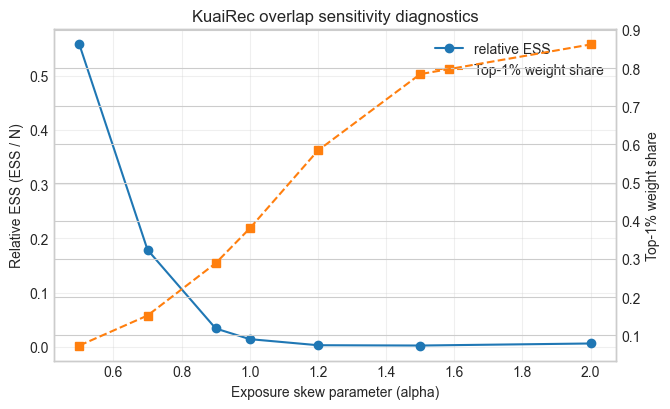

Saved: c:\Users\prana\OneDrive\Documents\thesis\pranathi3\results\section7\section7_overlap_sensitivity_kuairec.generated.20260323_222220.png


In [ ]:

# --- Missing Experiment 1: Overlap sensitivity sweep (KuaiRec) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _safe_out(path: str) -> str:
    return safe_out_path(path) if 'safe_out_path' in globals() else path


def _ess_and_top_share_from_prop(item_ids: pd.Series, prop_map: pd.Series, eps: float = 1e-8):
    p = item_ids.map(prop_map).astype(float).clip(lower=eps)
    w = 1.0 / p.values
    ess = float((w.sum() ** 2) / np.square(w).sum())
    rel_ess = ess / len(w)
    top1 = max(1, int(0.01 * len(w)))
    top_share = float(np.sort(w)[-top1:].sum() / w.sum())
    return rel_ess, top_share


kuairec_path = os.path.join(PRANATHI3, 'data', 'kuairec_data', 'kuairec_combined.csv')
kuairec_df = pd.read_csv(kuairec_path)
item_col = 'itemId' if 'itemId' in kuairec_df.columns else 'item_id'

base_counts = kuairec_df[item_col].value_counts().astype(float)
base_p = (base_counts / base_counts.sum())

# alpha>1 => sharper exposure (worse overlap), alpha<1 => flatter exposure (better overlap)
alphas = [0.5, 0.7, 0.9, 1.0, 1.2, 1.5, 2.0]
rows = []
for a in alphas:
    p_a = np.power(base_p.values, a)
    p_a = p_a / p_a.sum()
    p_map = pd.Series(p_a, index=base_p.index)
    rel_ess, top_share = _ess_and_top_share_from_prop(kuairec_df[item_col], p_map)
    rows.append({
        'Dataset': 'KUAIREC',
        'alpha_exposure_skew': float(a),
        'relative_ESS': float(rel_ess),
        'top1pct_weight_share': float(top_share),
        'N': int(len(kuairec_df)),
    })

df_overlap = pd.DataFrame(rows).sort_values('alpha_exposure_skew')
display(df_overlap)

csv_overlap = _safe_out(os.path.join(SECTION7_DIR, 'section7_overlap_sensitivity_kuairec.generated.csv'))
df_overlap.to_csv(csv_overlap, index=False)
print('Saved:', csv_overlap)

fig, ax1 = plt.subplots(figsize=(6.8, 4.2))
ax1.plot(df_overlap['alpha_exposure_skew'], df_overlap['relative_ESS'], marker='o', label='relative ESS')
ax1.set_xlabel('Exposure skew parameter (alpha)')
ax1.set_ylabel('Relative ESS (ESS / N)')
ax1.set_title('KuaiRec overlap sensitivity diagnostics')
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(df_overlap['alpha_exposure_skew'], df_overlap['top1pct_weight_share'], marker='s', linestyle='--', label='Top-1% weight share', color='tab:orange')
ax2.set_ylabel('Top-1% weight share')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.tight_layout()
png_overlap = _safe_out(os.path.join(SECTION7_DIR, 'section7_overlap_sensitivity_kuairec.generated.png'))
plt.savefig(png_overlap, dpi=220)
plt.show()
print('Saved:', png_overlap)

,Dataset,fraction,sample_size,relative_ESS_mean,relative_ESS_std,repeats
7,COAT,0.01,1000,0.697344,8.653847e-03,5
8,COAT,0.05,1000,0.696877,7.352870e-03,5
9,COAT,0.10,1160,0.699990,5.686971e-03,5
10,COAT,0.25,2900,0.805197,8.242226e-03,5
11,COAT,0.50,5800,0.875728,6.144730e-03,5
12,COAT,0.75,8700,0.891723,3.416649e-03,5
13,COAT,1.00,11600,0.900872,7.021667e-17,5
0,YAHOO,0.01,3117,0.464937,5.855447e-03,5
1,YAHOO,0.05,15585,0.357460,1.112587e-02,5
2,YAHOO,0.10,31170,0.376618,4.397441e-03,5


Saved: c:\Users\prana\OneDrive\Documents\thesis\pranathi3\results\section7\section7_randomization_fraction_sweep.generated.20260323_222221.csv


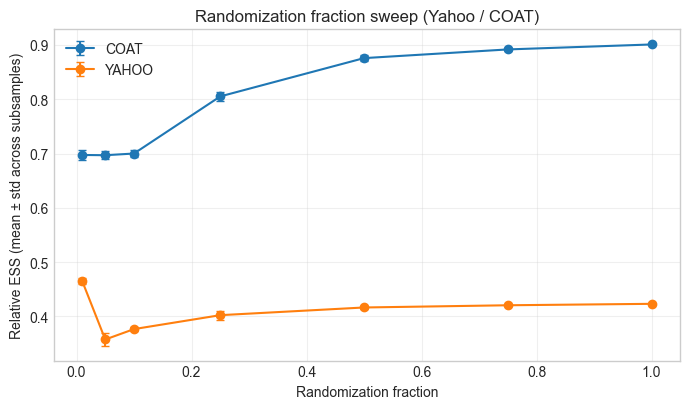

Saved: c:\Users\prana\OneDrive\Documents\thesis\pranathi3\results\section7\section7_randomization_fraction_sweep.generated.20260323_222221.png


In [10]:
# --- Missing Experiment 2: Randomization fraction sweep (Yahoo/COAT) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
fractions = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 1.00]
repeats = 5


def _rel_ess_for_sample(df: pd.DataFrame, item_col: str, idx: np.ndarray) -> float:
    sub = df.iloc[idx]
    counts = sub[item_col].value_counts().astype(float)
    p = counts / counts.sum()
    prop = sub[item_col].map(p).astype(float)
    w = 1.0 / prop.values
    ess = float((w.sum() ** 2) / np.square(w).sum())
    return float(ess / len(w))


yahoo_path = os.path.join(PRANATHI3, 'data', 'yahoo_data', 'user.txt')
coat_path = os.path.join(PRANATHI3, 'data', 'coat_data', 'coat_data', 'coat', 'coat_combined.csv')

yahoo_df = pd.read_csv(yahoo_path, names=['userId', 'itemId', 'rating'])
coat_df = pd.read_csv(coat_path)

rows = []
for dataset, df, item_col in [
    ('YAHOO', yahoo_df, 'itemId'),
    ('COAT', coat_df, 'itemId'),
]:
    n = len(df)
    for f in fractions:
        k = max(1000, int(n * f)) if n > 1000 else max(10, int(n * f))
        k = min(k, n)
        vals = []
        for r in range(repeats):
            idx = rng.choice(n, size=k, replace=False)
            vals.append(_rel_ess_for_sample(df, item_col, idx))
        rows.append({
            'Dataset': dataset,
            'fraction': float(f),
            'sample_size': int(k),
            'relative_ESS_mean': float(np.mean(vals)),
            'relative_ESS_std': float(np.std(vals)),
            'repeats': repeats,
        })

df_frac = pd.DataFrame(rows).sort_values(['Dataset', 'fraction'])
display(df_frac)

csv_frac = _safe_out(os.path.join(SECTION7_DIR, 'section7_randomization_fraction_sweep.generated.csv'))
df_frac.to_csv(csv_frac, index=False)
print('Saved:', csv_frac)

fig, ax = plt.subplots(figsize=(7.0, 4.2))
for ds in sorted(df_frac['Dataset'].unique()):
    d = df_frac[df_frac['Dataset'] == ds]
    ax.errorbar(d['fraction'], d['relative_ESS_mean'], yerr=d['relative_ESS_std'], marker='o', capsize=3, label=ds)
ax.set_xlabel('Randomization fraction')
ax.set_ylabel('Relative ESS (mean ± std across subsamples)')
ax.set_title('Randomization fraction sweep (Yahoo / COAT)')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
png_frac = _safe_out(os.path.join(SECTION7_DIR, 'section7_randomization_fraction_sweep.generated.png'))
plt.savefig(png_frac, dpi=220)
plt.show()
print('Saved:', png_frac)

,Dataset,sample_size,sample_fraction_of_kuairec,relative_ESS_mean,relative_ESS_std
0,KUAIREC,11600,0.000926,0.650829,4.165885e-03
1,KUAIREC,125308,0.010000,0.202001,1.000092e-03
2,KUAIREC,311704,0.024875,0.113934,5.771159e-04
3,KUAIREC,626540,0.050000,0.074977,4.994578e-04
4,KUAIREC,1253080,0.100000,0.051040,9.543570e-04
5,KUAIREC,3132701,0.250000,0.030841,3.664063e-04
6,KUAIREC,6265403,0.500000,0.020909,1.815215e-04
7,KUAIREC,12530806,1.000000,0.014034,2.491005e-17


Saved: c:\Users\prana\OneDrive\Documents\thesis\pranathi3\results\section7\section7_kuairec_downsampling_sweep.generated.20260323_222244.csv


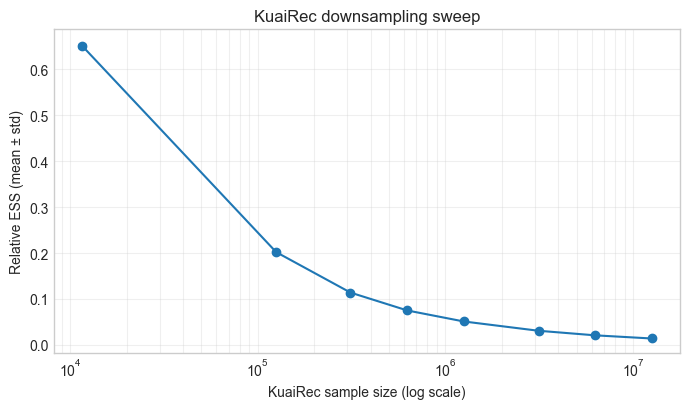

Saved: c:\Users\prana\OneDrive\Documents\thesis\pranathi3\results\section7\section7_kuairec_downsampling_sweep.generated.20260323_222245.png


In [11]:
# --- Missing Experiment 3: KuaiRec downsampling sweep ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)
kuairec_path = os.path.join(PRANATHI3, 'data', 'kuairec_data', 'kuairec_combined.csv')
yahoo_path = os.path.join(PRANATHI3, 'data', 'yahoo_data', 'user.txt')
coat_path = os.path.join(PRANATHI3, 'data', 'coat_data', 'coat_data', 'coat', 'coat_combined.csv')

k_df = pd.read_csv(kuairec_path)
y_df = pd.read_csv(yahoo_path, names=['userId', 'itemId', 'rating'])
c_df = pd.read_csv(coat_path)

item_col_k = 'itemId' if 'itemId' in k_df.columns else 'item_id'

# Include explicit dataset-size-matching budgets plus fractions of full KuaiRec
downsample_sizes = sorted(set([
    int(len(c_df)),
    int(len(y_df)),
    int(len(k_df) * 0.01),
    int(len(k_df) * 0.05),
    int(len(k_df) * 0.10),
    int(len(k_df) * 0.25),
    int(len(k_df) * 0.50),
    int(len(k_df)),
]))
downsample_sizes = [s for s in downsample_sizes if 1000 <= s <= len(k_df)]

rows = []
for size in downsample_sizes:
    vals = []
    for r in range(5):
        idx = rng.choice(len(k_df), size=size, replace=False)
        sub = k_df.iloc[idx]
        counts = sub[item_col_k].value_counts().astype(float)
        p = counts / counts.sum()
        prop = sub[item_col_k].map(p).astype(float)
        w = 1.0 / prop.values
        ess = float((w.sum() ** 2) / np.square(w).sum())
        vals.append(float(ess / len(sub)))
    rows.append({
        'Dataset': 'KUAIREC',
        'sample_size': int(size),
        'sample_fraction_of_kuairec': float(size / len(k_df)),
        'relative_ESS_mean': float(np.mean(vals)),
        'relative_ESS_std': float(np.std(vals)),
    })

df_down = pd.DataFrame(rows).sort_values('sample_size')
display(df_down)

csv_down = _safe_out(os.path.join(SECTION7_DIR, 'section7_kuairec_downsampling_sweep.generated.csv'))
df_down.to_csv(csv_down, index=False)
print('Saved:', csv_down)

fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.errorbar(df_down['sample_size'], df_down['relative_ESS_mean'], yerr=df_down['relative_ESS_std'], marker='o', capsize=3)
ax.set_xscale('log')
ax.set_xlabel('KuaiRec sample size (log scale)')
ax.set_ylabel('Relative ESS (mean ± std)')
ax.set_title('KuaiRec downsampling sweep')
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
png_down = _safe_out(os.path.join(SECTION7_DIR, 'section7_kuairec_downsampling_sweep.generated.png'))
plt.savefig(png_down, dpi=220)
plt.show()
print('Saved:', png_down)

,Dataset,Architecture,NDCG@10_Naive,NDCG@10_IPS,NDCG@10_DR,Delta_IPS_minus_Naive,Delta_DR_minus_Naive,Delta_DR_minus_IPS
1,COAT,LightGCN,0.797862,0.788868,0.793085,-0.008993,-0.004777,0.004216
2,COAT,MF,0.776202,0.772609,0.770589,-0.003593,-0.005613,-0.002020
0,COAT,NCF,0.810506,0.816404,0.818523,0.005898,0.008017,0.002119
4,KUAIREC,LightGCN,0.441073,0.457300,0.440034,0.016227,-0.001039,-0.017266
5,KUAIREC,MF,0.409650,0.444005,0.408139,0.034355,-0.001511,-0.035866
3,KUAIREC,NCF,0.470857,0.474454,0.475142,0.003597,0.004284,0.000687
7,YAHOO,LightGCN,0.834610,0.832562,0.834192,-0.002048,-0.000418,0.001630
8,YAHOO,MF,0.833183,0.834391,0.834434,0.001207,0.001250,0.000043
6,YAHOO,NCF,0.829503,0.829826,0.828830,0.000323,-0.000673,-0.000997


Saved: c:\Users\prana\OneDrive\Documents\thesis\pranathi3\results\section7\section7_dr_vs_ips_summary.generated.20260323_222245.csv


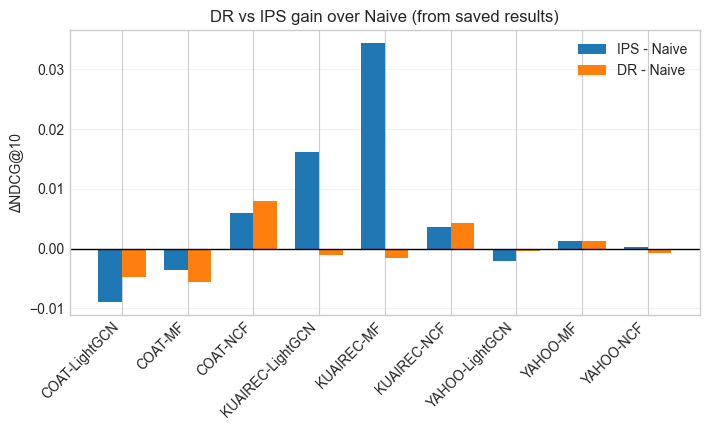

Saved: c:\Users\prana\OneDrive\Documents\thesis\pranathi3\results\section7\section7_dr_vs_ips_summary.generated.20260323_222245.png


In [12]:
# --- Optional completion: DR vs IPS contribution summary from saved results ---
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

rows = []
for fn in os.listdir(RESULTS_DIR):
    if not fn.startswith('debiasing_results_') or not fn.endswith('.csv'):
        continue
    if fn in {'debiasing_results.csv'}:
        continue
    path = os.path.join(RESULTS_DIR, fn)
    df = pd.read_csv(path)
    if not {'Model', 'NDCG@10'}.issubset(df.columns):
        continue

    m = fn.lower()
    if 'kuairec' in m:
        dataset = 'KUAIREC'
    elif 'yahoo' in m:
        dataset = 'YAHOO'
    elif 'coat' in m:
        dataset = 'COAT'
    else:
        dataset = 'UNKNOWN'

    if 'lightgcn' in m:
        arch = 'LightGCN'
    elif re.search(r'_mf\.csv$', fn, re.IGNORECASE):
        arch = 'MF'
    elif fn in {'debiasing_results_yahoo.csv', 'debiasing_results_coat.csv', 'debiasing_results_kuairec.csv'}:
        arch = 'NCF'
    else:
        arch = 'UNKNOWN'

    vals = {r['Model']: float(r['NDCG@10']) for _, r in df.iterrows()}
    naive = vals.get('Naive ERM', np.nan)
    ips = vals.get('IPS', np.nan)
    dr = vals.get('DR', np.nan)

    rows.append({
        'Dataset': dataset,
        'Architecture': arch,
        'NDCG@10_Naive': naive,
        'NDCG@10_IPS': ips,
        'NDCG@10_DR': dr,
        'Delta_IPS_minus_Naive': ips - naive if pd.notna(ips) and pd.notna(naive) else np.nan,
        'Delta_DR_minus_Naive': dr - naive if pd.notna(dr) and pd.notna(naive) else np.nan,
        'Delta_DR_minus_IPS': dr - ips if pd.notna(dr) and pd.notna(ips) else np.nan,
    })


df_dr = pd.DataFrame(rows).sort_values(['Dataset', 'Architecture'])
display(df_dr)

csv_dr = _safe_out(os.path.join(SECTION7_DIR, 'section7_dr_vs_ips_summary.generated.csv'))
df_dr.to_csv(csv_dr, index=False)
print('Saved:', csv_dr)

plot = df_dr.dropna(subset=['Delta_IPS_minus_Naive', 'Delta_DR_minus_Naive']).copy()
if not plot.empty:
    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    x = np.arange(len(plot))
    ax.bar(x - 0.18, plot['Delta_IPS_minus_Naive'], width=0.36, label='IPS - Naive')
    ax.bar(x + 0.18, plot['Delta_DR_minus_Naive'], width=0.36, label='DR - Naive')
    ax.axhline(0.0, color='black', linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(plot['Dataset'] + '-' + plot['Architecture'], rotation=45, ha='right')
    ax.set_ylabel('ΔNDCG@10')
    ax.set_title('DR vs IPS gain over Naive (from saved results)')
    ax.legend()
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    png_dr = _safe_out(os.path.join(SECTION7_DIR, 'section7_dr_vs_ips_summary.generated.png'))
    plt.savefig(png_dr, dpi=220)
    plt.show()
    print('Saved:', png_dr)

### Section 7.4 support — transferability and matched-regime summaries

This block builds two lightweight summaries from generated Section 7 artifacts:

- **Transferability summary:** dataset-level consistency of IPS gains, with ESS/bias context.
- **Matched-regime summary:** KuaiRec downsample sizes whose relative ESS is closest to Yahoo/COAT regimes.

These tables support cross-scale interpretation when full cross-dataset re-training transfer is out of scope.

In [13]:
# --- Section 7.4 summaries: transferability + matched regimes ---
import os
import numpy as np
import pandas as pd

summary_files = [
    os.path.join(SECTION7_DIR, 'section7_summary.generated.csv'),
    os.path.join(SECTION7_DIR, 'section7_summary.generated.20260320_185503.csv'),
]
summary_path = next((p for p in summary_files if os.path.exists(p)), None)
if summary_path is None:
    raise FileNotFoundError('No section7_summary file found in results/section7/.')

summary = pd.read_csv(summary_path)
summary = summary[
    summary['Dataset'].isin(['COAT', 'YAHOO', 'KUAIREC'])
    & summary['Architecture'].isin(['MF', 'NCF', 'LightGCN'])
].copy()

df_transfer = summary.groupby('Dataset', as_index=False).agg(
    mean_ips_gain=('DeltaNDCG@10_IPS_minus_Naive', 'mean'),
    std_ips_gain=('DeltaNDCG@10_IPS_minus_Naive', 'std'),
    relESS=('relative_ESS', 'mean'),
    absBiasNDCG10=('|Bias_NDCG@10|', 'mean'),
)
cons = (
    summary.groupby('Dataset')['DeltaNDCG@10_IPS_minus_Naive']
    .apply(lambda s: float((s > 0).mean()))
    .reset_index(name='ips_gain_sign_consistency')
)
df_transfer = df_transfer.merge(cons, on='Dataset', how='left')
df_transfer['diagnostic_tag'] = np.where(
    (df_transfer['mean_ips_gain'] > 0) & (df_transfer['relESS'] > 0.6),
    'stable-positive',
    np.where(
        (df_transfer['mean_ips_gain'] > 0) & (df_transfer['relESS'] <= 0.6),
        'positive-but-unstable-risk',
        'limited-or-negative-gain',
    ),
)

display(df_transfer)

csv_transfer = _safe_out(os.path.join(SECTION7_DIR, 'section7_transferability_summary.generated.csv'))
df_transfer.to_csv(csv_transfer, index=False)
print('Saved:', csv_transfer)

kdown_files = [
    os.path.join(SECTION7_DIR, 'section7_kuairec_downsampling_sweep.generated.csv'),
]
kdown_path = next((p for p in kdown_files if os.path.exists(p)), None)
if kdown_path is None:
    raise FileNotFoundError('Run KuaiRec downsampling sweep cell first.')

kdown = pd.read_csv(kdown_path)
targets = summary.groupby('Dataset', as_index=False)['relative_ESS'].mean()
rows = []
for _, t in targets.iterrows():
    ds = t['Dataset']
    target = t['relative_ESS']
    if pd.isna(target):
        continue
    j = (kdown['relative_ESS_mean'] - target).abs().idxmin()
    r = kdown.loc[j]
    rows.append({
        'target_dataset': ds,
        'target_relESS': float(target),
        'matched_kuairec_sample_size': int(r['sample_size']),
        'matched_kuairec_relESS': float(r['relative_ESS_mean']),
        'abs_gap': float(abs(r['relative_ESS_mean'] - target)),
    })

df_match = pd.DataFrame(rows).sort_values('abs_gap')
display(df_match)

csv_match = _safe_out(os.path.join(SECTION7_DIR, 'section7_kuairec_matched_regimes.generated.csv'))
df_match.to_csv(csv_match, index=False)
print('Saved:', csv_match)

,Dataset,mean_ips_gain,std_ips_gain,relESS,absBiasNDCG10,ips_gain_sign_consistency,diagnostic_tag
0,COAT,-0.002229,0.007538,0.900872,NaN,0.333333,limited-or-negative-gain
1,KUAIREC,0.025291,0.012819,0.784961,NaN,1.000000,stable-positive
2,YAHOO,-0.000172,0.001683,0.431624,NaN,0.666667,limited-or-negative-gain


Saved: c:\Users\prana\OneDrive\Documents\thesis\pranathi3\results\section7\section7_transferability_summary.generated.20260323_222246.csv


,target_dataset,target_relESS,matched_kuairec_sample_size,matched_kuairec_relESS,abs_gap
1,KUAIREC,0.784961,11600,0.650829,0.134132
2,YAHOO,0.431624,11600,0.650829,0.219205
0,COAT,0.900872,11600,0.650829,0.250044


Saved: c:\Users\prana\OneDrive\Documents\thesis\pranathi3\results\section7\section7_kuairec_matched_regimes.generated.20260323_222246.csv
